# Student Name: Hu Jinnan
<br>

All files can be found in:

In [28]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Introduction:
<br>

Nowadays, an increasing number of people travel to different cities in various countries for study or work purposes, and some may even settle down in new cities. However, the economic and cultural differences between cities are significant, leading to vastly different living experiences. Therefore, it is necessary to understand the situations of popular cities in advance and select those with the best living experiences to plan for study or work in advance.

Hence, I chose a dataset that includes the cost of living in different cities across many countries as the source of data for analysis. This dataset contains city-level data from 15 countries, covering two consecutive years (2024 and 2025). Each record captures important economic and lifestyle indicators, such as average monthly rent, food and transportation cost indices, internet fees, average wages, and multiple quality-of-life indicators including safety, healthcare, and pollution levels.

The specific contents are as follows:

1.Country – Country name

2.City – City name

3.Year – Observation year (2024 or 2025)

4.Average_Monthly_Rent_USD – Average monthly rent in USD

5.Food_Cost_Index – Relative food cost index

6.Transport_Cost_Index – Relative transportation cost index

7.Internet_Cost_USD – Monthly internet cost in USD

8.Average_Monthly_Salary_USD – Average monthly salary in USD

9.Quality_of_Life_Index – Overall quality of life score

10.Safety_Index – Safety and crime perception score

11.Healthcare_Index – Healthcare quality score

12.Pollution_Index – Environmental pollution level

The source link of the dataset is as follows: https://www.kaggle.com/datasets/abdullahmeo/world-cost-of-living-and-quality-of-life-20242025

In [29]:
#Read data
url1 = "https://raw.githubusercontent.com/HuJinnan/Homework_o1_Games-and-Decisions-in-Data-Analysis-and-Modelling/refs/heads/main/world_cost_of_living_quality_of_life_2024_2025.csv"
all_cities = pd.read_csv(url1)
print(all_cities.head())

    Country       City  Year  Average_Monthly_Rent_USD  Food_Cost_Index  \
0  Pakistan    Karachi  2024                      1160            62.84   
1  Pakistan    Karachi  2025                       430            51.44   
2  Pakistan     Lahore  2024                      1047            51.61   
3  Pakistan     Lahore  2025                       862            76.77   
4  Pakistan  Islamabad  2024                      2361           106.59   

   Transport_Cost_Index  Internet_Cost_USD  Average_Monthly_Salary_USD  \
0                 94.58              65.73                        1066   
1                107.89              85.76                        3033   
2                 76.73              48.99                        2647   
3                108.83              54.67                        4156   
4                 61.32              23.30                        1963   

   Quality_of_Life_Index  Safety_Index  Healthcare_Index  Pollution_Index  
0                  65.00    

# Data treatment:
<br>

Since the most popular countries for Chinese people to settle in recent years are China, the United States, Japan, Canada and Australia, I have chosen cities in these three countries as the research subjects. Therefore, I have made the following operations on the original data:

1. Only select cities in the target countries.

2. Only select data for the year 2025.

3. Delete the columns of "Country" and "Year".

In [30]:
#Chose cities of China, Japan and USA, year of 2025
countries = ['China', 'USA', 'Japan','Australia', 'Canada' ]
target_cities = all_cities.copy()
rows_drop = []
for idx,row in target_cities.iterrows():
    if row['Country'] not in countries:
        rows_drop.append(idx)
target_cities = target_cities.drop(rows_drop)
target_cities = target_cities[target_cities['Year'] == 2025].reset_index(drop=True)
target_cities = target_cities.drop(columns='Country')
target_cities = target_cities.drop(columns='Year')
target_cities = target_cities.reset_index(drop=True)
print(target_cities)
target_cities.to_csv("target_cities.csv", index=False)

           City  Average_Monthly_Rent_USD  Food_Cost_Index  \
0      New York                      1095           106.26   
1   Los Angeles                      1557            73.63   
2       Chicago                      1961            60.14   
3       Toronto                       769            68.56   
4     Vancouver                      1369           114.04   
5      Montreal                      1646            89.90   
6        Sydney                      1949            94.03   
7     Melbourne                      1172            76.44   
8      Brisbane                      1792           102.67   
9         Tokyo                      1716           107.53   
10        Osaka                      1013           113.44   
11        Kyoto                      1440           117.43   
12      Beijing                       770            53.18   
13     Shanghai                      1228            78.78   
14     Shenzhen                      1562            60.53   

    Tra

After selecting the target city, you can see that the remaining number of selectable cities is 15. Next, we will normalize the data in each column so that their value ranges become 0-100.

Among them, ['Average_Monthly_Salary_USD', 'Quality_of_Life_Index', 'Safety_Index', 'Healthcare_Index'] are all positive indicators. The larger the value, the more livable the city. Therefore, the following formula is used for normalization:  $\frac{Raw-Min}{Max-Min}\cdot100$.

On the contrary, the remaining indicators, namely ['Average_Monthly_Rent_USD', 'Food_Cost_Index', 'Transport_Cost_Index', 'Internet_Cost_USD', 'Pollution_Index'], are all negative indicators. The larger the value, the less livable the city is. Therefore, another formula is used for normalization: $(1-\frac{Raw - Min}{Max - Min})\cdot100$.

In [31]:
#Normalization
advantages = ['Average_Monthly_Salary_USD', 'Quality_of_Life_Index', 'Safety_Index', 'Healthcare_Index']
disadvantages = ['Average_Monthly_Rent_USD', 'Food_Cost_Index', 'Transport_Cost_Index', 'Internet_Cost_USD', 'Pollution_Index']

target_cities_norm = target_cities.copy()
for col in advantages + disadvantages:
    target_cities_norm[col] = target_cities_norm[col].astype(float)
for adv in advantages:
    max_val = target_cities_norm[adv].max()
    min_val = target_cities_norm[adv].min()
    target_cities_norm.loc[:, adv] = (target_cities_norm[adv] - min_val) / (max_val - min_val) * 100
for disadv in disadvantages:
    max_val = target_cities_norm[disadv].max()
    min_val = target_cities_norm[disadv].min()
    target_cities_norm.loc[:, disadv] = (1 - (target_cities_norm[disadv] - min_val) / (max_val - min_val)) * 100

target_cities_norm = target_cities_norm.round(2)
print(target_cities_norm)
target_cities_norm.to_csv("target_cities_norm.csv", index=False)

           City  Average_Monthly_Rent_USD  Food_Cost_Index  \
0      New York                     72.65            17.39   
1   Los Angeles                     33.89            68.17   
2       Chicago                      0.00            89.17   
3       Toronto                    100.00            76.06   
4     Vancouver                     49.66             5.28   
5      Montreal                     26.43            42.85   
6        Sydney                      1.01            36.42   
7     Melbourne                     66.19            63.80   
8      Brisbane                     14.18            22.97   
9         Tokyo                     20.55            15.41   
10        Osaka                     79.53             6.21   
11        Kyoto                     43.71             0.00   
12      Beijing                     99.92           100.00   
13     Shanghai                     61.49            60.16   
14     Shenzhen                     33.47            88.56   

    Tra

# Find the Pareto set:
<br>

Now, after normalization, the larger the data in each column, the better the corresponding plan. We can start to look for the Pareto set. The specific method is as follows: Select city X and compare it with other cities Y. If there is no city Y that has better indicators in all aspects than X, then city X belongs to the Pareto set.

In [32]:
#Find the Pareto set
def find_pareto_set(Data):
    data = Data.copy()
    data = data.drop(columns='City')
    pareto_set_idx= []
    pareto_set = []

    for idx_i, row in data.iterrows():
        flag =  True
        for idx_j, row in data.iterrows():
            if idx_i == idx_j:
                continue
            else:
                j_ge_i = (data.loc[idx_j] >= data.loc[idx_i]).all()  #All indicators are greater than or equal to i.
                j_gt_i = (data.loc[idx_j] > data.loc[idx_i]).any()   #At least one indicator is greater than i.
                dominated_flag = j_ge_i and j_gt_i  #Simultaneous satisfaction is dominance.

                if dominated_flag == True:
                    flag = False
                    break
        if flag == True:
            pareto_set_idx.append(idx_i)
    for idx in pareto_set_idx:
        pareto_set.append(Data.loc[idx,'City'])
    return pareto_set


pareto_set = find_pareto_set(target_cities_norm)
print(f"The number of Pareto element is: {len(pareto_set)}")
print(f"The cities in Pareto set are: {pareto_set}")

The number of Pareto element is: 15
The cities in Pareto set are: ['New York', 'Los Angeles', 'Chicago', 'Toronto', 'Vancouver', 'Montreal', 'Sydney', 'Melbourne', 'Brisbane', 'Tokyo', 'Osaka', 'Kyoto', 'Beijing', 'Shanghai', 'Shenzhen']


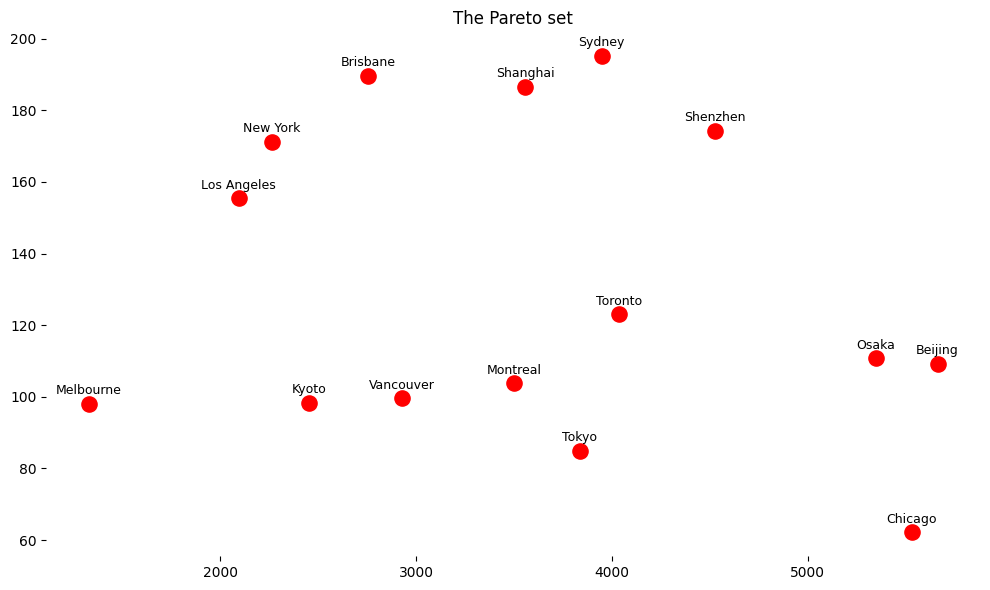

In [33]:
#Show the Pareto set
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,6))
x_col = 'Average_Monthly_Salary_USD'
y_col = 'Quality_of_Life_Index'

for idx in target_cities.index:
    city = target_cities.loc[idx, 'City']
    x = target_cities.loc[idx, x_col]
    y = target_cities.loc[idx, y_col]

    if city in pareto_set:
        plt.scatter(x, y, color='red', s=120)
    else:
        plt.scatter(x, y, color='lightblue', s=120)
    plt.annotate(city, (x, y), xytext=(0, 7), textcoords='offset points', fontsize=9, ha='center')

plt.title('The Pareto set')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

The Pareto set we found consists of 15 cities, which are represented by the red dots in the graph. It is obvious that due to the large number of evaluation indicators we have, this method cannot identify the best city nor eliminate the worst one. We need to conduct further analysis to find the optimal solution.

# Finding the best choice:<br>

## Weighted linear combination of criteria
<br>

Firstly, in order to select the optimal solution using the weighted linear combination of criteria method, I have decided to assign the following weights to each column of indicators:

{"Average_Monthly_Rent_USD": 0.15, "Food_Cost_Index": 0.1, "Transport_Cost_Index": 0.05, "Internet_Cost_USD": 0.05, "Average_Monthly_Salary_USD": 0.15, "Quality_of_Life_Index": 0.1, "Safety_Index": 0.15, "Healthcare_Index": 0.15, "Pollution_Index": 0.1}.

These weights are entirely based on my own subjective judgment and there is no particularly fixed principle. However, I believe this is reasonable because everyone has their own judgment on the importance of different aspects.

In [34]:
#Weighted linear combination of criteria
weight = {"Average_Monthly_Rent_USD": 0.15, "Food_Cost_Index": 0.1, "Transport_Cost_Index": 0.05, "Internet_Cost_USD": 0.05, "Average_Monthly_Salary_USD": 0.15, "Quality_of_Life_Index": 0.1, "Safety_Index": 0.15, "Healthcare_Index": 0.15, "Pollution_Index": 0.1}
target_cities_weighted = target_cities_norm.copy()

for key in weight.keys():
    target_cities_weighted[key] = weight[key] * target_cities_weighted[key]

#Find the best city:
target_cities_weighted['Final_score'] = target_cities_weighted.select_dtypes(include='number').sum(axis=1)
idx_max = np.argmax(target_cities_weighted['Final_score'])
target_cities_weighted.to_csv("target_cities_weighted.csv", index=False)
print(f"The best city by Weighted linear is: {target_cities_weighted.loc[idx_max, 'City']}")
print(f"The best score is: {target_cities_weighted.loc[idx_max, 'Final_score']:.4}")

The best city by Weighted linear is: Shanghai
The best score is: 67.26


By using the weights I assigned, the highest score of 67.26 was calculated, and the most livable city is Shanghai, China.

## Weighted distance to the "ideal" point:
<br>

Next, I will still use the weights assigned previously to calculate the distance of each city from the ideal point. Since our previous normalization operation ensured that the maximum value of each attribute is 100, the numerical coordinates of the ideal point are all 100.
So, the formula for calculating distance is: $d = \sqrt{\sum_{i}^{n}\sum_{j}^{m} Weight_j \cdot (Norm_{ij} - 100)^2}$.

In [35]:
#Find the ideal point
target_cities_distance = target_cities_norm.copy()
for idx in target_cities_distance.columns:
    if idx != 'City':
        target_cities_distance[idx] = ((target_cities_distance[idx] - 100) ** 2) * weight[idx]
distance = target_cities_distance.select_dtypes(include='number').sum(axis=1)
for i in range(len(distance)):
    distance[i] = np.sqrt(distance[i])
target_cities_distance['Distance'] = distance
idx_min = np.argmin(target_cities_distance['Distance'])
print(f"The best city by Ideal distance is: {target_cities_distance.loc[idx_min, 'City']}")
print(f"The best distance is: {target_cities_distance.loc[idx_min, 'Distance']:.4}")
target_cities_distance.to_csv("target_cities_distance.csv", index=False)

The best city by Ideal distance is: Shanghai
The best distance is: 39.53


The calculated minimum distance is 39.53, and the corresponding best city remains Shanghai, China. This is normal. When the weights do not change, the results obtained by the two methods should be consistent.

## Scoring rules: Borda rule
<br>

Next, I will use the Borda rule to find the optimal solution. But first, I need to construct the voting results based on the normalized data table. I consider each column of indicators as a category of voters, and the ranking of the values in that column is the voting result of that category of voters. To reflect the previous weights, I decide that the number of voters in each category is equal to the weight multiplied by 100.

In [36]:
#Calculating voter number
voter_number = {}
for col in target_cities_norm.columns.drop('City'):
    voter_number[col] = int(weight[col] * 100)

print(f"Voter numbers for each group: {voter_number}\n")

#Constructing voting table
voting_table = pd.DataFrame()
for col in target_cities_norm.columns.drop('City'):
    ranking = target_cities_norm.sort_values(col, ascending=False)['City'].tolist()
    voting_table[col] = ranking
voting_table.index = range(1, len(voting_table) + 1)
print("The voting result is as follows:")
print(voting_table)
voting_table.to_csv("voting_table.csv")

Voter numbers for each group: {'Average_Monthly_Rent_USD': 15, 'Food_Cost_Index': 10, 'Transport_Cost_Index': 5, 'Internet_Cost_USD': 5, 'Average_Monthly_Salary_USD': 15, 'Quality_of_Life_Index': 10, 'Safety_Index': 15, 'Healthcare_Index': 15, 'Pollution_Index': 10}

The voting result is as follows:
   Average_Monthly_Rent_USD Food_Cost_Index Transport_Cost_Index  \
1                   Toronto         Beijing                Kyoto   
2                   Beijing         Chicago             Montreal   
3                     Osaka        Shenzhen                Osaka   
4                  New York         Toronto             New York   
5                 Melbourne     Los Angeles              Toronto   
6                  Shanghai       Melbourne              Beijing   
7                 Vancouver        Shanghai            Vancouver   
8                     Kyoto        Montreal              Chicago   
9               Los Angeles          Sydney            Melbourne   
10                 

After obtaining the voting results, I defined the last place as 0 points, and for each increase in ranking by one place, the score also increases by one. Now, let's calculate the score for each city.

In [37]:
#Calculate voting scores based on ranking
num_cities = len(voting_table)
scores = {}
for col in voting_table.columns:
    num_voters = voter_number[col]
    for rank, city in enumerate(voting_table[col]):
        score = (num_cities - rank - 1) * num_voters
        if city not in scores:
            scores[city] = 0
        scores[city] += score
voting_score = pd.DataFrame(list(scores.items()), columns=['City', 'Voting_score'])
voting_score = voting_score.sort_values('Voting_score', ascending=False).reset_index(drop=True)
idx_max = np.argmax(voting_score['Voting_score'])
print(f"The best city by Borda rule is: {voting_score.loc[idx_max, 'City']}")
print(f"The best voting score is: {voting_score.loc[idx_max, 'Voting_score']}")

The best city by Borda rule is: Toronto
The best voting score is: 985


The highest score calculated is 985, and the best city is Toronto in Canada. Clearly, the result is different from the previous one. Let's continue the analysis to see how the final change is.

## Rules based on majority relations: Copeland Rule
<br>

Next, I will still use this voting table and calculate it using the Copeland Rule.

In [38]:
# Calculate Copeland scores
cities = voting_table.iloc[:, 0].tolist()
scores_copeland = {city: 0 for city in cities}

for i, city_i in enumerate(cities):
    for j, city_j in enumerate(cities):
        if i >= j:
            continue
        votes_i = 0
        votes_j = 0
        for col in voting_table.columns:
            num_voters = voter_number[col]
            ranking = voting_table[col].tolist()
            if ranking.index(city_i) < ranking.index(city_j):
                votes_i += num_voters
            else:
                votes_j += num_voters
        if votes_i > votes_j:
            scores_copeland[city_i] += 1
            scores_copeland[city_j] -= 1
        elif votes_j > votes_i:
            scores_copeland[city_j] += 1

copeland_score = pd.DataFrame(list(scores_copeland.items()), columns=['City', 'Copeland_score'])
copeland_score = copeland_score.sort_values('Copeland_score', ascending=False).reset_index(drop=True)
idx_max = np.argmax(copeland_score['Copeland_score'])
print(f"The best city by Copeland rule is: {copeland_score.loc[idx_max, 'City']}")
print(f"The Copeland score is: {copeland_score.loc[idx_max, 'Copeland_score']}")

The best city by Copeland rule is: Toronto
The Copeland score is: 12


The calculated best score is 12, and the best city remains Toronto in Canada.

## Rules based on the tournament matrix: Maximin rule
<br>

Finally, use the Maximin rule to calculate the best city.

In [39]:
# Calculate Maximin scores
num_cities = len(cities)
maximin_scores = {city: float('inf') for city in cities}

for i, city_i in enumerate(cities):
    for j, city_j in enumerate(cities):
        if i == j:
            continue
        votes_i = 0
        votes_j = 0
        for col in voting_table.columns:
            num_voters = voter_number[col]
            ranking = voting_table[col].tolist()
            if ranking.index(city_i) < ranking.index(city_j):
                votes_i += num_voters
            else:
                votes_j += num_voters
        maximin_scores[city_i] = min(maximin_scores[city_i], votes_i)

maximin_score = pd.DataFrame(list(maximin_scores.items()), columns=['City', 'Maximin_score'])
maximin_score = maximin_score.sort_values('Maximin_score', ascending=False).reset_index(drop=True)
idx_max = np.argmax(maximin_score['Maximin_score'])
print(f"The best city by Maximin rule is: {maximin_score.loc[idx_max, 'City']}")
print(f"The Maximin score is: {maximin_score.loc[idx_max, 'Maximin_score']}")

The best city by Maximin rule is: Toronto
The Maximin score is: 45


The calculated best score is 45, and the best city remains Toronto in Canada.

# Conclusion:
<br>

1. In this analysis of 15 target cities, positive indicators (such as salary, quality of life, safety, and healthcare) and negative indicators (such as rent, costs, and pollution) were normalized with weights applied.

2. Using weighted linear combination and weighted distance to the ideal point, Shanghai ranked best due to high salary, good quality of life, and moderate costs.

3. In contrast, under rules: Borda, Copeland, and Maximin, which rely on relative comparisons and rankings, Toronto emerged as the top city, reflecting its stable performance across indicators with minimal impact from extreme values.

4. Overall, the difference illustrates that the first two methods emphasize absolute values and weights, while social choice rules focus on relative advantage and consistency, explaining why Shanghai and Toronto are preferred under different approaches.
